# 03 · ShapeDNA: hearing the shape of a hippocampus

**SpectralBrain tutorial series — notebook 3 of 10.** (Previous: the I/O layer.)

Notebook 1 ended on a cliff-hanger: rigid motion leaves the spectrum unchanged,
so the eigenvalues themselves are a **pose-free fingerprint of shape**. That
fingerprint is **ShapeDNA** (Reuter, Wolter & Peinecke 2006). Here we compute it
on the four HippUnfold hippocampi from notebook 2 and use it to quantify
left–right asymmetry and between-subject differences — without ever aligning the
shapes.

### Learning objectives
1. Explain *why* the eigenvalue sequence encodes geometry (heat-trace asymptotics).
2. Compute ShapeDNA with `compute_shapedna` and read its normalization options.
3. Make ShapeDNA **scale-invariant** and measure shape distance between structures.


## 1. What the spectrum knows

ShapeDNA is just the truncated, ordered eigenvalue sequence
$(\lambda_1, \lambda_2, \dots, \lambda_k)$ (we skip $\lambda_0 = 0$). Why should a
list of numbers describe a shape? The **heat-trace asymptotic expansion** answers
this. The sum $\sum_k e^{-\lambda_k t}$ behaves, for small diffusion time $t$, as

$$\sum_{k} e^{-\lambda_k t} \;\sim\; \frac{1}{4\pi t}\Big( A \;-\; \sqrt{\pi t}\,L \;+\; \tfrac{t}{3}\!\int_{\mathcal S} K\,dA \;+\;\cdots \Big),$$

where $A$ is the surface area, $L$ the boundary length, and $\int K\,dA$ the
integrated Gaussian curvature (a topological constant by Gauss–Bonnet). So the
eigenvalues collectively **carry area, perimeter, and curvature** — the geometry
of the structure. Weyl's law (notebook 1) is the leading term. ShapeDNA packs
this information into a short, comparable vector.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain as sb
from _tutorial_utils import data_path, spectrum_plot

# Load the four HippUnfold hippocampi (sub03/sub04, left/right) from notebook 2.
hipp = {}
for sid in ["sub03", "sub04"]:
    for hemi in ["L", "R"]:
        p = data_path("hippunfold", sid, f"hemi-{hemi}_space-T1w_den-8k_label-hipp_midthickness.surf.gii")
        v, f = sb.load_gifti_surface(p)
        hipp[f"{sid}_{hemi}"] = sb.BrainMesh(v, f)

decs = {name: m.decompose(k=80) for name, m in hipp.items()}
print("decomposed:", ", ".join(decs))

[06/09/26 01:58:40] INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 01:58:41] INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 01:58:42] INFO     Laplacian (cotangent): N=8192, nnz=56578

[06/09/26 01:58:43] INFO     Laplacian (cotangent): N=8192, nnz=56578

decomposed: sub03_L, sub03_R, sub04_L, sub04_R


## 2. Computing ShapeDNA

`compute_shapedna(dec, normalize=...)` returns the descriptor. The `normalize`
argument is the important choice:

- `normalize='none'` — raw eigenvalues. These depend on **size**: a bigger
  hippocampus has smaller eigenvalues (recall $\lambda \propto 1/\text{area}$).
- `normalize='area'` (default) — scales out the surface area, so ShapeDNA reflects
  **shape, not size**. Use this to compare structures of different sizes.


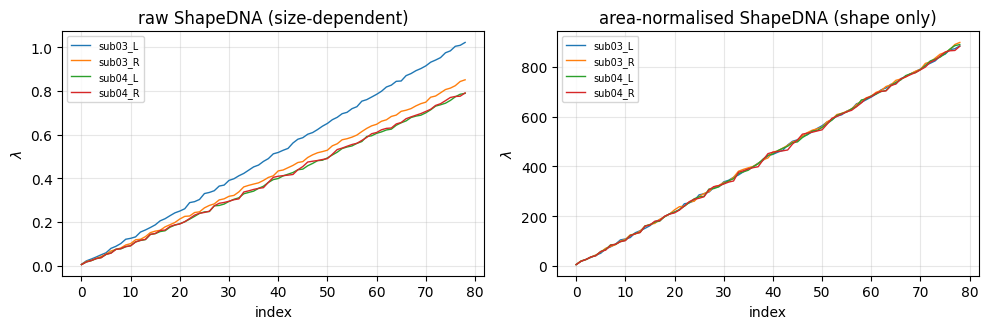

In [2]:
dna_raw  = {n: np.asarray(sb.compute_shapedna(d, normalize="none")) for n, d in decs.items()}
dna_norm = {n: np.asarray(sb.compute_shapedna(d, normalize="area")) for n, d in decs.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for n in decs:
    axes[0].plot(dna_raw[n], lw=1, label=n)
    axes[1].plot(dna_norm[n], lw=1, label=n)
axes[0].set_title("raw ShapeDNA (size-dependent)")
axes[1].set_title("area-normalised ShapeDNA (shape only)")
for ax in axes:
    ax.set_xlabel("index"); ax.set_ylabel(r"$\lambda$"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Scale invariance, demonstrated

If ShapeDNA truly describes shape, scaling a hippocampus should leave the
*normalised* descriptor unchanged while the *raw* one shifts. We scale `sub03_L`
by a factor of 2 (its area grows $4\times$, so raw eigenvalues shrink $4\times$)
and check both descriptors.

In [3]:
big = sb.BrainMesh(hipp["sub03_L"].vertices * 2.0, hipp["sub03_L"].faces)
dec_big = big.decompose(k=80)

raw_ratio  = np.asarray(sb.compute_shapedna(dec_big, normalize="none")) / dna_raw["sub03_L"]
norm_diff  = np.abs(np.asarray(sb.compute_shapedna(dec_big, normalize="area")) - dna_norm["sub03_L"])
print(f"raw eigenvalue ratio (scaled / original): mean = {raw_ratio.mean():.3f}  (expected 0.25)")
print(f"normalised ShapeDNA: max |difference| = {norm_diff.max():.3e}  (expected ~0)")
print("\n-> raw ShapeDNA tracks size; area-normalised ShapeDNA is scale-invariant.")

[06/09/26 01:58:45] INFO     Laplacian (cotangent): N=8192, nnz=56578

raw eigenvalue ratio (scaled / original): mean = 0.250  (expected 0.25)
normalised ShapeDNA: max |difference| = 2.387e-12  (expected ~0)

-> raw ShapeDNA tracks size; area-normalised ShapeDNA is scale-invariant.


## 4. Comparing shapes: ShapeDNA distance

`shapedna_distance(a, b, metric=...)` reduces two fingerprints to a single number.
With area-normalised descriptors it measures pure shape dissimilarity. We build
the full $4\times4$ distance matrix over the hippocampi.

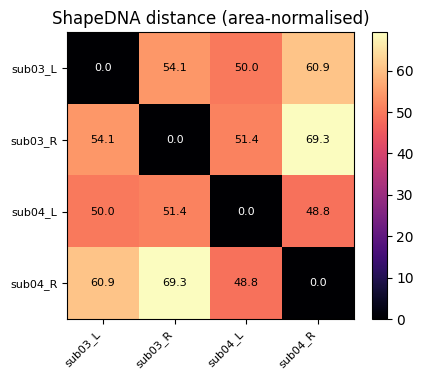

In [4]:
names = list(decs)
dnas = {n: sb.compute_shapedna(decs[n], normalize="area") for n in names}
D = np.zeros((4, 4))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        D[i, j] = sb.shapedna_distance(dnas[a], dnas[b], metric="euclidean")

fig, ax = plt.subplots(figsize=(4.6, 3.9))
im = ax.imshow(D, cmap="magma")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8); ax.set_yticklabels(names, fontsize=8)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{D[i, j]:.1f}", ha="center", va="center",
                color="white" if D[i, j] < D.max() * 0.6 else "black", fontsize=8)
ax.set_title("ShapeDNA distance (area-normalised)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## 5. Reading the matrix: asymmetry and clustering

Two questions the matrix answers at a glance: how different are a subject's **left
and right** hippocampi (asymmetry), and do **subjects** separate? A dendrogram on
the same distances makes the grouping explicit.

sub03 left–right ShapeDNA asymmetry: 54.12


sub04 left–right ShapeDNA asymmetry: 48.83


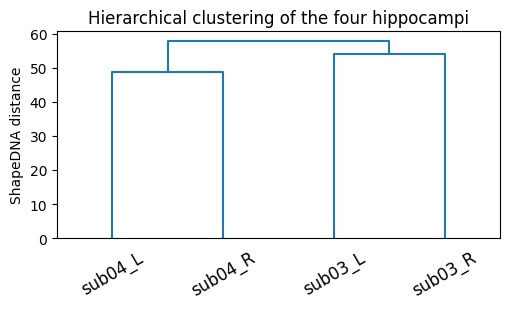

In [5]:
# Left-right asymmetry per subject = distance between that subject's L and R.
for sid in ["sub03", "sub04"]:
    i, j = names.index(f"{sid}_L"), names.index(f"{sid}_R")
    print(f"{sid} left–right ShapeDNA asymmetry: {D[i, j]:.2f}")

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
Z = linkage(squareform(D, checks=False), method="average")
fig, ax = plt.subplots(figsize=(5.2, 3.2))
dendrogram(Z, labels=names, ax=ax, leaf_rotation=30)
ax.set_ylabel("ShapeDNA distance"); ax.set_title("Hierarchical clustering of the four hippocampi")
plt.tight_layout(); plt.show()

## 6. What ShapeDNA cannot do

ShapeDNA is **global**: it summarises the whole structure in one vector. That is
its strength (compact, pose-free, fast) and its limit — it cannot tell you *where*
two shapes differ. A focal change in the hippocampal head and the same-magnitude
change in the tail can produce identical ShapeDNA. Two more caveats: the
truncation $k$ trades detail against noise (small eigenvalues are stable, high
ones are mesh-dependent), and degenerate meshes distort the spectrum (notebook 2's
`quality_report`). To **localise** differences we need per-vertex descriptors —
the subject of notebook 4.

## Exercises

1. **Truncation.** Recompute the distance matrix using only the first 20
   eigenvalues, then 80. Does the left–right ordering change? Which $k$ is stable?
2. **Metric choice.** Rebuild the matrix with `metric='cosine'` and compare it to
   the Euclidean one. When would cosine (shape of the spectrum, ignoring overall
   magnitude) be preferable?
3. **Add a cortex.** Compute ShapeDNA for `sub01`'s left pial surface and confirm
   it sits *far* from every hippocampus — sanity that the descriptor separates
   genuinely different structures.
4. **Normalisation matters.** Repeat the clustering with `normalize='none'`. Do
   the subjects still group, or does size dominate?
5. **Asymmetry index.** Define a per-subject asymmetry score as the L–R ShapeDNA
   distance divided by the mean within-hemisphere distance to the other subject.
   Which subject is more asymmetric?


## What's next

ShapeDNA gave us one number per structure. **Notebook 04** moves from global to
**local**: the Heat Kernel Signature assigns every *vertex* a multi-scale
descriptor, letting us paint shape information across the hippocampal surface and
see exactly where geometry varies.
